In [1]:
from tensorflow.keras.datasets import mnist
(X_train,y_train), (X_test,y_test)=mnist.load_data()

2026-03-28 00:51:53.099900: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 00:51:53.168607: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-28 00:51:54.531574: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

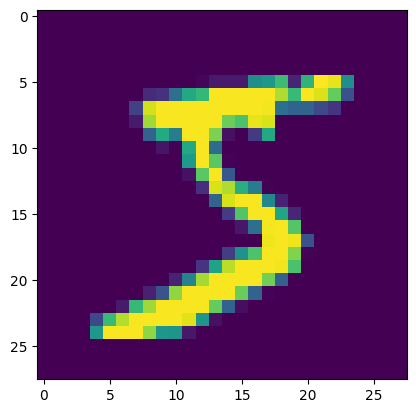

In [4]:
plt.imshow(X_train[0])

In [5]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

knn.fit(X_train_flat,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
import time
start=time.time()
y_pred=knn.predict(X_test_flat)
print(time.time()-start)

18.964354038238525


In [8]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9688

<h3><b>Using PCA

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [10]:
X_train_flat=scaler.fit_transform(X_train_flat)
X_test_flat=scaler.transform(X_test_flat)

In [11]:
from sklearn.decomposition import PCA
pca=PCA(n_components=95)

In [12]:
X_train_trf=pca.fit_transform(X_train_flat)
X_test_trf=pca.transform(X_test_flat)

In [13]:
X_train_trf.shape

(60000, 95)

In [14]:
knn=KNeighborsClassifier()

In [15]:
knn.fit(X_train_trf,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
y_pred=knn.predict(X_test_trf)
accuracy_score(y_test,y_pred)

0.9583

7


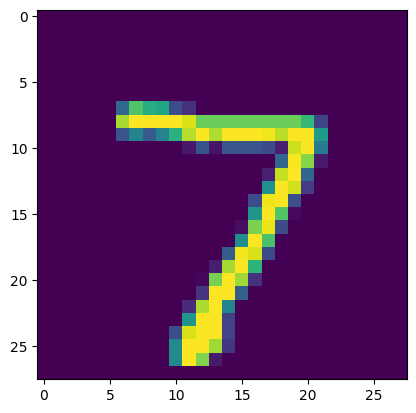

In [17]:
plt.imshow(X_test[0])
print(y_pred[0])

In [22]:
import plotly.express as px

fig = px.scatter(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    color=y_train.astype(str),
    render_mode="svg"   # 🔥 IMPORTANT
)

fig.show()

In [23]:
pca.explained_variance_

array([40.48763511, 29.24169752, 26.81180449, 20.68661822, 18.07665012,
       15.73317787, 13.79060909, 12.51758909, 11.00679527, 10.05049705,
        9.62045779,  8.63097356,  7.99159687,  7.81488215,  7.37553786,
        7.13058751,  6.71398002,  6.60400749,  6.40604846,  6.23737743,
        5.93229172,  5.76059855,  5.48403364,  5.31859721,  5.12873534,
        4.96062446,  4.90533662,  4.70843497,  4.5291976 ,  4.39470849,
        4.27522172,  4.21399693,  4.09838079,  4.03181137,  3.97713624,
        3.86052409,  3.80864021,  3.72563426,  3.64393543,  3.4416973 ,
        3.41624517,  3.36378527,  3.25773631,  3.23620323,  3.204781  ,
        3.17911021,  3.14205728,  3.08588859,  3.06076556,  3.03759974,
        2.90171955,  2.86408562,  2.84980787,  2.8237422 ,  2.76632955,
        2.71778127,  2.69168208,  2.65850712,  2.61669482,  2.57622805,
        2.52662224,  2.493722  ,  2.46947024,  2.43689501,  2.40883423,
        2.40117231,  2.37950231,  2.3161347 ,  2.26774369,  2.24

In [24]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]], shape=(95, 784))

In [25]:
pca.explained_variance_ratio_

array([0.05646717, 0.04078272, 0.0373938 , 0.02885115, 0.02521109,
       0.0219427 , 0.01923344, 0.01745799, 0.01535092, 0.0140172 ,
       0.01341743, 0.01203742, 0.0111457 , 0.01089924, 0.01028649,
       0.00994487, 0.00936383, 0.00921046, 0.00893437, 0.00869913,
       0.00827363, 0.00803417, 0.00764846, 0.00741772, 0.00715293,
       0.00691847, 0.00684136, 0.00656675, 0.00631677, 0.0061292 ,
       0.00596255, 0.00587716, 0.00571592, 0.00562307, 0.00554682,
       0.00538418, 0.00531182, 0.00519606, 0.00508211, 0.00480006,
       0.00476456, 0.00469139, 0.00454349, 0.00451346, 0.00446963,
       0.00443383, 0.00438215, 0.00430382, 0.00426878, 0.00423647,
       0.00404696, 0.00399447, 0.00397456, 0.00393821, 0.00385814,
       0.00379043, 0.00375403, 0.00370776, 0.00364944, 0.00359301,
       0.00352382, 0.00347794, 0.00344411, 0.00339868, 0.00335955,
       0.00334886, 0.00331864, 0.00323026, 0.00316277, 0.00313244,
       0.00310731, 0.00307243, 0.00304914, 0.00302717, 0.00299

In [27]:
np.cumulative_sum(pca.explained_variance_ratio_)

array([0.05646717, 0.09724989, 0.13464369, 0.16349484, 0.18870593,
       0.21064863, 0.22988207, 0.24734006, 0.26269099, 0.27670818,
       0.29012561, 0.30216303, 0.31330873, 0.32420796, 0.33449446,
       0.34443932, 0.35380315, 0.36301361, 0.37194798, 0.3806471 ,
       0.38892074, 0.39695491, 0.40460336, 0.41202109, 0.41917402,
       0.42609249, 0.43293384, 0.43950059, 0.44581736, 0.45194656,
       0.45790911, 0.46378627, 0.46950219, 0.47512526, 0.48067208,
       0.48605627, 0.49136809, 0.49656415, 0.50164626, 0.50644631,
       0.51121087, 0.51590227, 0.52044576, 0.52495921, 0.52942885,
       0.53386268, 0.53824483, 0.54254865, 0.54681743, 0.5510539 ,
       0.55510086, 0.55909534, 0.5630699 , 0.56700811, 0.57086624,
       0.57465667, 0.57841069, 0.58211845, 0.5857679 , 0.5893609 ,
       0.59288472, 0.59636266, 0.59980677, 0.60320546, 0.606565  ,
       0.60991386, 0.6132325 , 0.61646276, 0.61962553, 0.62275797,
       0.62586528, 0.62893771, 0.63198685, 0.63501403, 0.63800

In [28]:
pca=PCA(n_components=None)
X_train_trf=pca.fit_transform(X_train_flat)
X_test_trf=pca.transform(X_test_flat)

In [29]:
pca.explained_variance_ratio_

array([5.64671692e-02, 4.07827199e-02, 3.73938042e-02, 2.88511485e-02,
       2.52110863e-02, 2.19426996e-02, 1.92334439e-02, 1.74579923e-02,
       1.53509230e-02, 1.40171960e-02, 1.34174302e-02, 1.20374194e-02,
       1.11456955e-02, 1.08992356e-02, 1.02864922e-02, 9.94486564e-03,
       9.36383280e-03, 9.21045666e-03, 8.93436778e-03, 8.69912619e-03,
       8.27363019e-03, 8.03417369e-03, 7.64845500e-03, 7.41772464e-03,
       7.15292868e-03, 6.91846831e-03, 6.84135964e-03, 6.56674546e-03,
       6.31676724e-03, 6.12919839e-03, 5.96255295e-03, 5.87716416e-03,
       5.71591699e-03, 5.62307416e-03, 5.54682002e-03, 5.38418374e-03,
       5.31182250e-03, 5.19605602e-03, 5.08211255e-03, 4.80005571e-03,
       4.76455820e-03, 4.69139360e-03, 4.54348956e-03, 4.51345787e-03,
       4.46963401e-03, 4.43383155e-03, 4.38215469e-03, 4.30381751e-03,
       4.26877901e-03, 4.23647017e-03, 4.04696121e-03, 3.99447403e-03,
       3.97456119e-03, 3.93820800e-03, 3.85813590e-03, 3.79042674e-03,
      

In [30]:
np.cumulative_sum(pca.explained_variance_ratio_)

array([0.05646717, 0.09724989, 0.13464369, 0.16349484, 0.18870593,
       0.21064863, 0.22988207, 0.24734006, 0.26269099, 0.27670818,
       0.29012561, 0.30216303, 0.31330873, 0.32420796, 0.33449446,
       0.34443932, 0.35380315, 0.36301361, 0.37194798, 0.3806471 ,
       0.38892074, 0.39695491, 0.40460336, 0.41202109, 0.41917402,
       0.42609249, 0.43293384, 0.43950059, 0.44581736, 0.45194656,
       0.45790911, 0.46378627, 0.46950219, 0.47512526, 0.48067208,
       0.48605627, 0.49136809, 0.49656415, 0.50164626, 0.50644631,
       0.51121087, 0.51590227, 0.52044576, 0.52495921, 0.52942885,
       0.53386268, 0.53824483, 0.54254865, 0.54681743, 0.5510539 ,
       0.55510086, 0.55909534, 0.5630699 , 0.56700811, 0.57086624,
       0.57465667, 0.57841069, 0.58211845, 0.5857679 , 0.5893609 ,
       0.59288472, 0.59636266, 0.59980677, 0.60320546, 0.606565  ,
       0.60991386, 0.6132325 , 0.61646276, 0.61962553, 0.62275797,
       0.62586528, 0.62893771, 0.63198685, 0.63501403, 0.63800

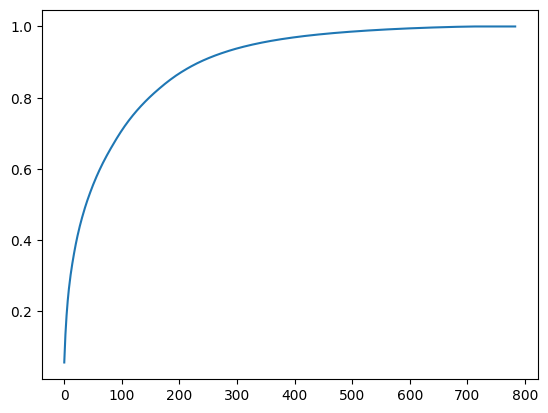

In [33]:
plt.plot(np.cumulative_sum(pca.explained_variance_ratio_))